<a href="https://colab.research.google.com/github/switlanakostyuk-ctrl/Apollo/blob/main/%22HW_11_3_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Seaborn_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [2]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

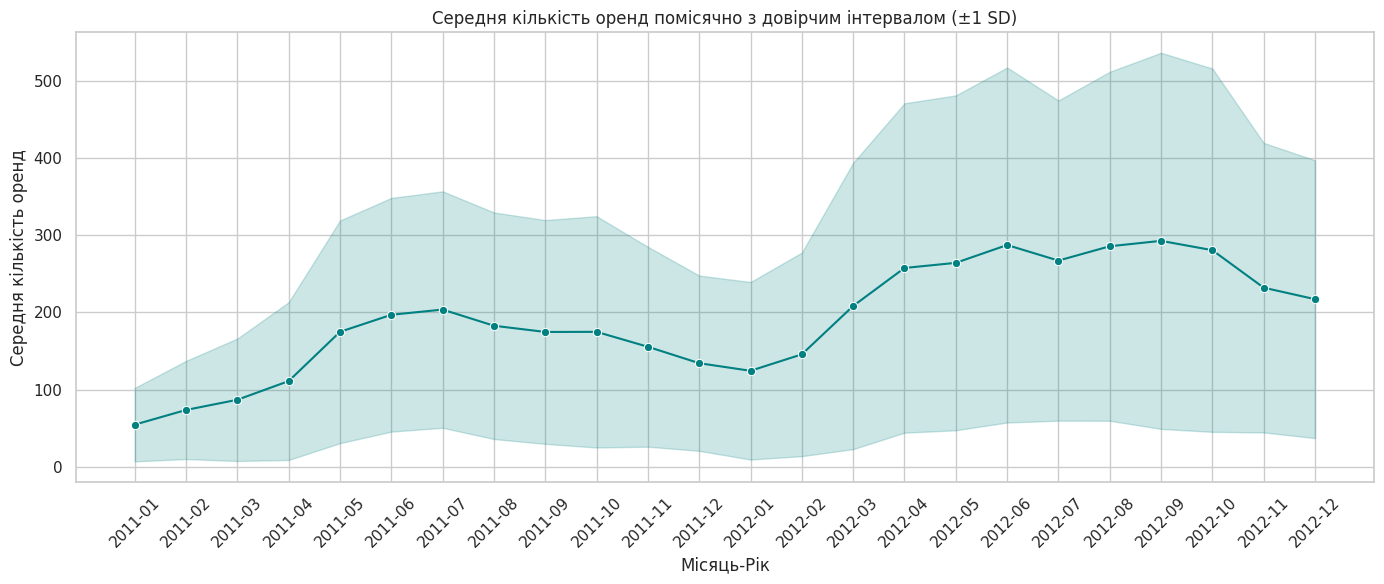

In [7]:
plt.figure(figsize=(14,6))

sns.lineplot( data=df, x='month_year',   y='count',
    errorbar='sd',      # 1 стандартне відхилення
    marker='o',
    color='teal')

plt.title('Середня кількість оренд помісячно з довірчим інтервалом (±1 SD)')
plt.xlabel('Місяць-Рік')
plt.ylabel('Середня кількість оренд')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Найбільша невизначеність даних там де ширша зафарбована область між min та max. На графіку припадає на вересень 2012 року. Це відбувається через нестабільну осінню погоду.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

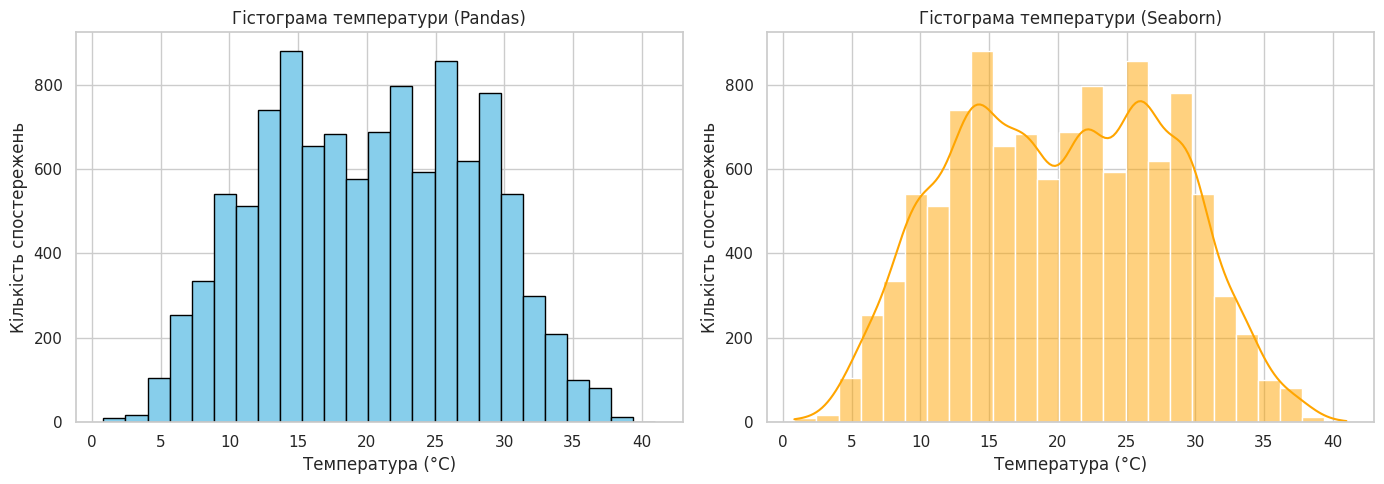

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(14,5))

df['temp'].plot.hist(   bins=25,    color='skyblue', edgecolor='black',   ax=axs[0])

axs[0].set_title('Гістограма температури (Pandas)')
axs[0].set_xlabel('Температура (°C)')
axs[0].set_ylabel('Кількість спостережень')


sns.histplot( data=df,    x='temp',    bins=25,  kde=True,  color='orange', ax=axs[1])

axs[1].set_title('Гістограма температури (Seaborn)')
axs[1].set_xlabel('Температура (°C)')
axs[1].set_ylabel('Кількість спостережень')

plt.tight_layout()
plt.show()

1. На мою думку, різниця між гістограмами майже не помітна. Гістограма Pandas виглядає простішою та більш “базовою”.Гістограма Seaborn має більш сучасний (легкий) стиль.
2. В Seaborn є згладжена крива, що дозволяє краще побачити форму розподілу температури без впливу розміру бінів.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

In [15]:
weather_labels = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'}

/tmp/ipython-input-1365920017.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels([weather_labels[i] for i in sorted(df['weather'].unique())])


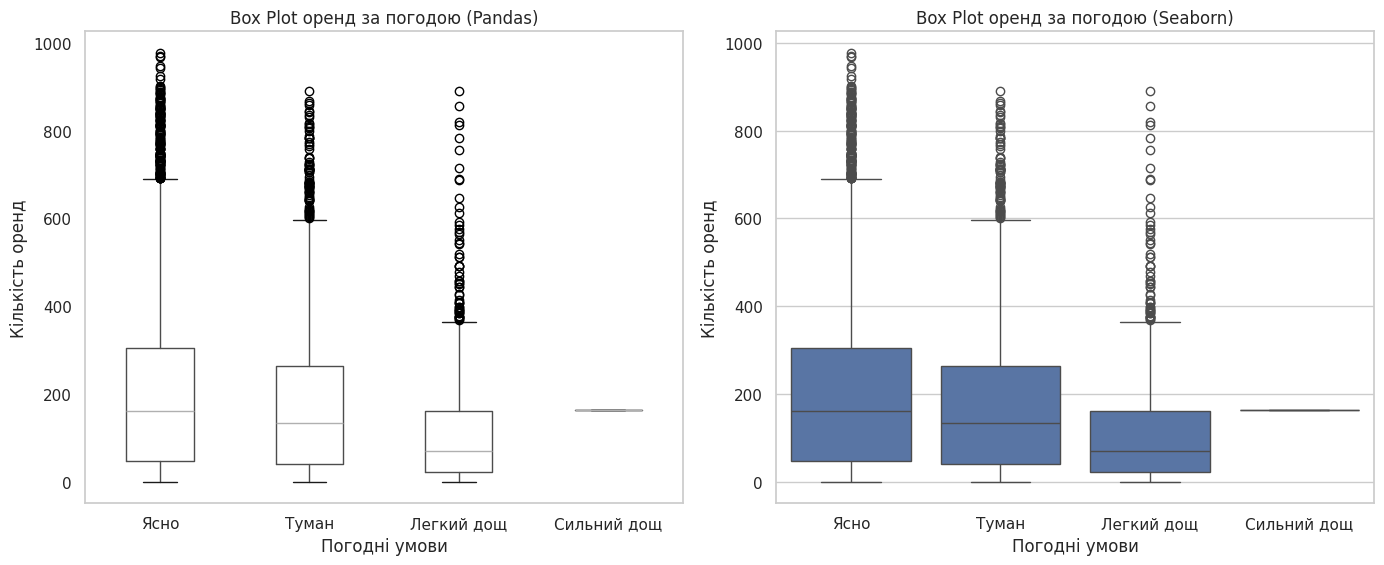

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(14,6))


df.boxplot(  column='count',   by='weather', ax=axs[0],    grid=False)

axs[0].set_title('Box Plot оренд за погодою (Pandas)')
axs[0].set_xlabel('Погодні умови')
axs[0].set_ylabel('Кількість оренд')
axs[0].set_xticklabels([weather_labels[i] for i in sorted(df['weather'].unique())])
plt.suptitle('')

sns.boxplot(    data=df,  x='weather',   y='count',   ax=axs[1])

axs[1].set_title('Box Plot оренд за погодою (Seaborn)')
axs[1].set_xlabel('Погодні умови')
axs[1].set_ylabel('Кількість оренд')
axs[1].set_xticklabels([weather_labels[i] for i in sorted(df['weather'].unique())])

plt.tight_layout()
plt.show()

Seaborn робить товстіші лінії медіани. Лінії та маркери викидів більш чіткі, а стиль графіка краще підходить для статистичного аналізу. Графік Pandas є простішим, але менш гнучким з точки зору дизайну.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5]),
 [Text(0.5, 0, 'temp'),
  Text(1.5, 0, 'atemp'),
  Text(2.5, 0, 'humidity'),
  Text(3.5, 0, 'windspeed'),
  Text(4.5, 0, 'casual'),
  Text(5.5, 0, 'registered'),
  Text(6.5, 0, 'count')])

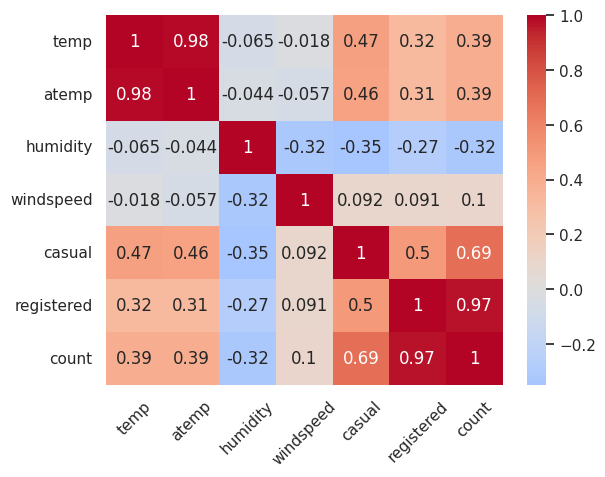

In [21]:
correlation = df[['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.xticks(rotation=45)

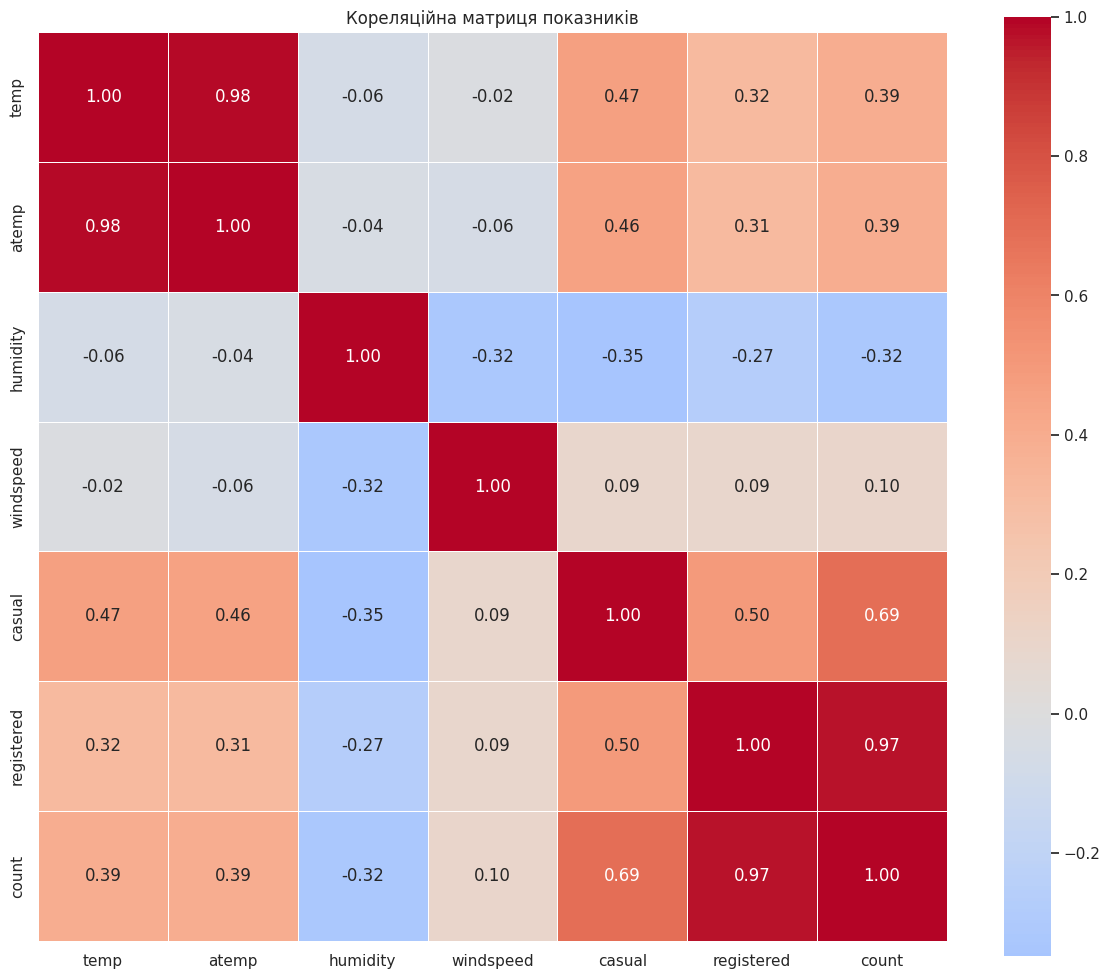

In [25]:
plt.figure(figsize=(12,10))
sns.heatmap(
    correlation,   annot=True,  cmap='coolwarm',  center=0,
    square=True, linewidths=0.5,  fmt=".2f")

plt.title('Кореляційна матриця показників')
plt.tight_layout()
plt.show()

1. Найсильнішу позитивну кореляцію з загальною кількістю оренд мають змінні registered та casual, що логічно, оскільки count є їх сумою. Також помірна позитивна кореляція спостерігається з температурою.

2. Між temp та atemp майже ідеальна кореляція, оскільки показник "відчувається як температура" розраховується на основі фактичної температури.

3. Негативна кореляція є між кількістю оренд та вологістю або погіршенням погодних умов, що можна пояснити зниженням попиту в менш комфортних погодних умовах.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


/tmp/ipython-input-317841260.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(  data=df, x='season',    y='count',  palette='Set2')


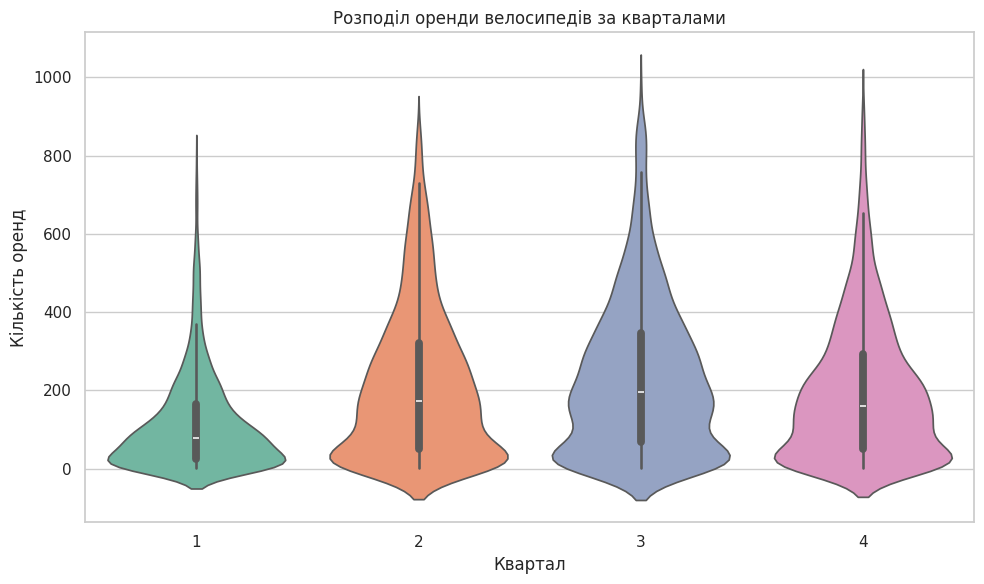

In [27]:
plt.figure(figsize=(10,6))

sns.violinplot(  data=df, x='season',    y='count',  palette='Set2')

plt.title('Розподіл оренди велосипедів за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренд')
plt.tight_layout()
plt.show()

1. Товщина показує щільність розподілу.
2. Найбільша варіабельність у Q3 (найвища скрипка). В теплі місяці попит сильно коливається.
3. Перевага violin plot над box plot полягає в тому, що він дозволяє побачити форму розподілу та можливі особливості даних, які не відображаються у стандартному box plot.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

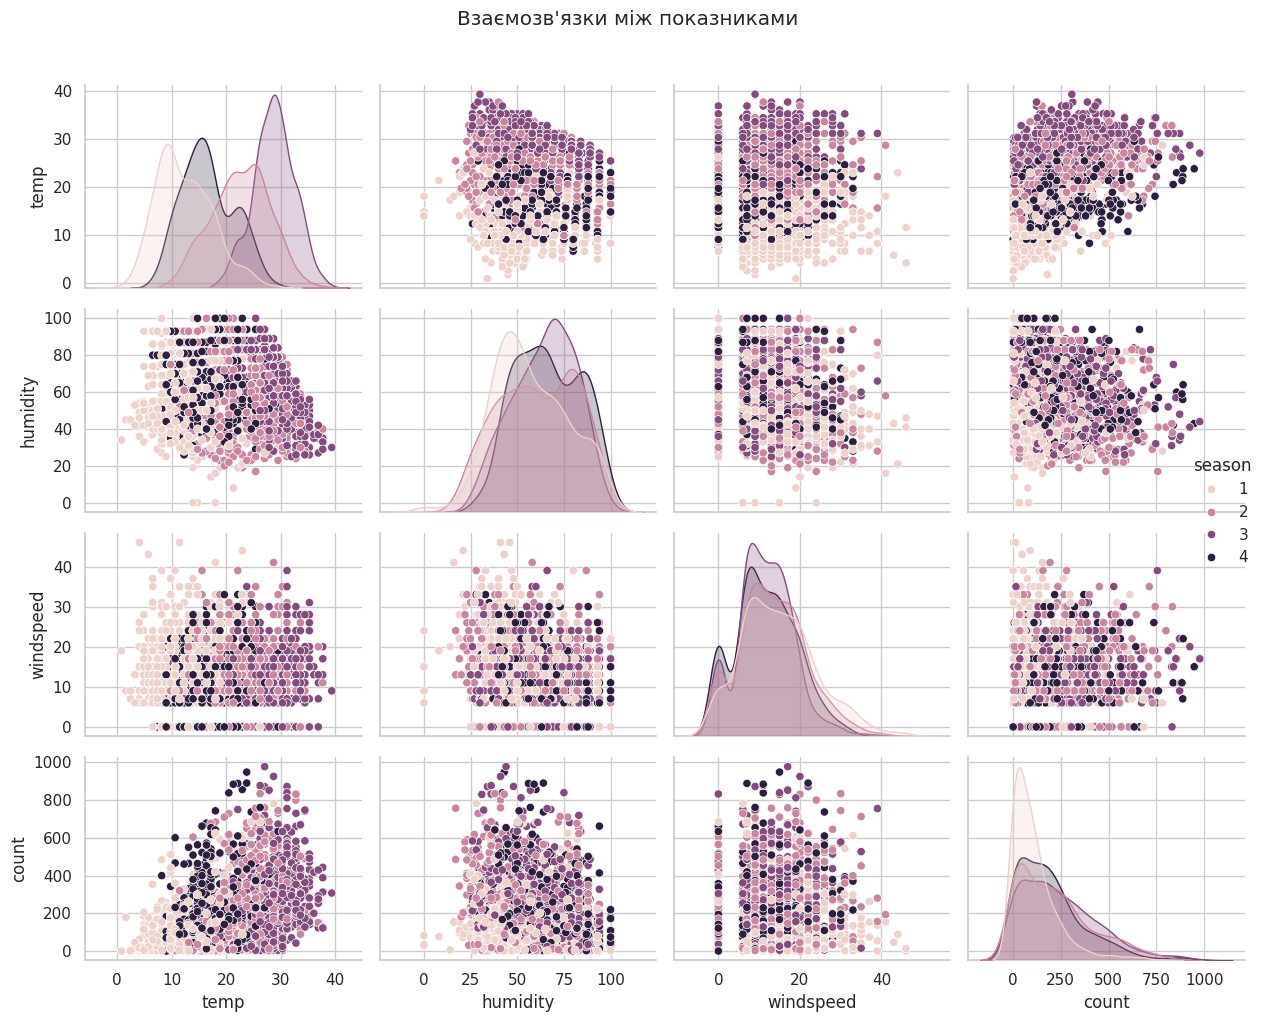

In [39]:
pair_df = df[['temp', 'humidity', 'windspeed', 'count', 'season']]

sns.pairplot(
    pair_df_sample,
    hue='season',
    diag_kind='kde',
    height=2.5,
    aspect=1.2)

plt.suptitle('Взаємозв\'язки між показниками', y=1.02)
plt.tight_layout()
plt.show()

Найсильніший лінійний зв’язок спостерігається між температурою (temp) та кількістю оренд (count). Зі збільшенням температури кількість оренд зростає
Найбільше між кварталами відрізняється температура (temp), оскільки її розподіл суттєво зміщується між різними кварталами.

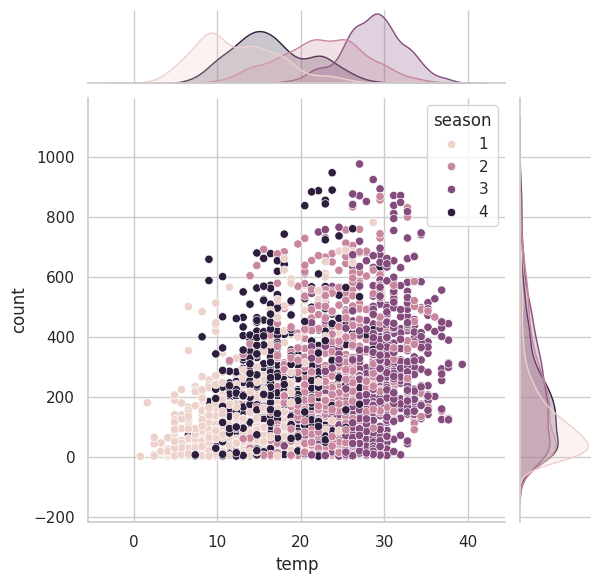

In [34]:
sns.jointplot(
    data=df.sample(frac=0.3, random_state=42),
    x='temp', y='count',
    hue='season',
    height=6 )

plt.show()

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

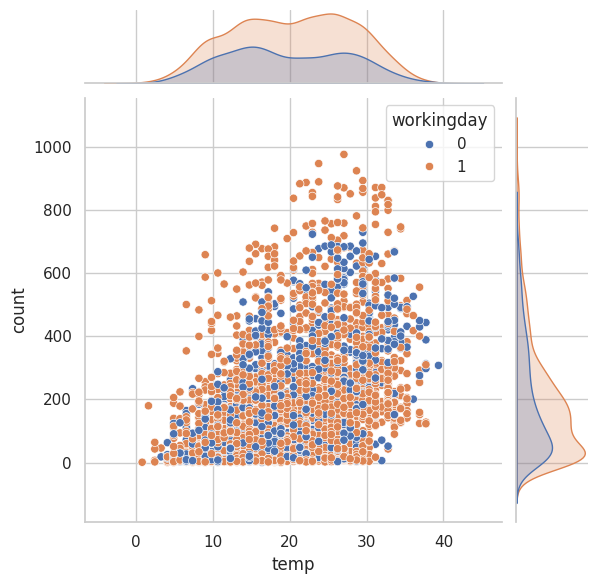

In [36]:
sns.jointplot(
    data=df.sample(frac=0.3, random_state=42),
    x='temp',  y='count',
    hue='workingday',
    height=6 )

plt.show()

1.Графіки по краях показують розподіл кожної змінної окремо:
верхній — розподіл температур
правий — розподіл кількості оренд

Вони дозволяють оцінити чи є зміщення розподілу, як відрізняється інтенсивність оренд у робочі та неробочі дні, яка є асиметрія або концентрація значень

2. У неробочі дні більш пікові значення.